# Exploratory Data Analysis — Fake News Detection
## WELFake Dataset
**Name:** Pulindu Pasanjith  
**Dataset:** WELFake — 72,134 news articles  
**Goal:** Understand the data distribution, word patterns, and class balance before model training.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print("✅ Libraries imported!")

✅ Libraries imported!


In [2]:
df = pd.read_csv('../data/welFake_cleaned.csv')

print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (72095, 2)

Column names: ['final_text', 'label']

First 5 rows:


,final_text,label
0,law enforcement high alert following threat co...,1
1,post vote hillary already,1
2,unbelievable obamas attorney general say charl...,1
3,bobby jindal raised hindu us story christian c...,0
4,satan russia unvelis image terrifying new supe...,1


## 1. Data Overview
Understanding the basic structure and content of the dataset.

In [3]:
print("Total articles:", len(df))
print("\nLabel distribution:")
print(df['label'].value_counts())
print("\nMissing values:")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)

Total articles: 72095

Label distribution:
label
1    37067
0    35028
Name: count, dtype: int64

Missing values:
final_text    54
label          0
dtype: int64

Data types:
final_text    object
label          int64
dtype: object


## 2. Class Distribution
Checking if the dataset is balanced between fake and real news.

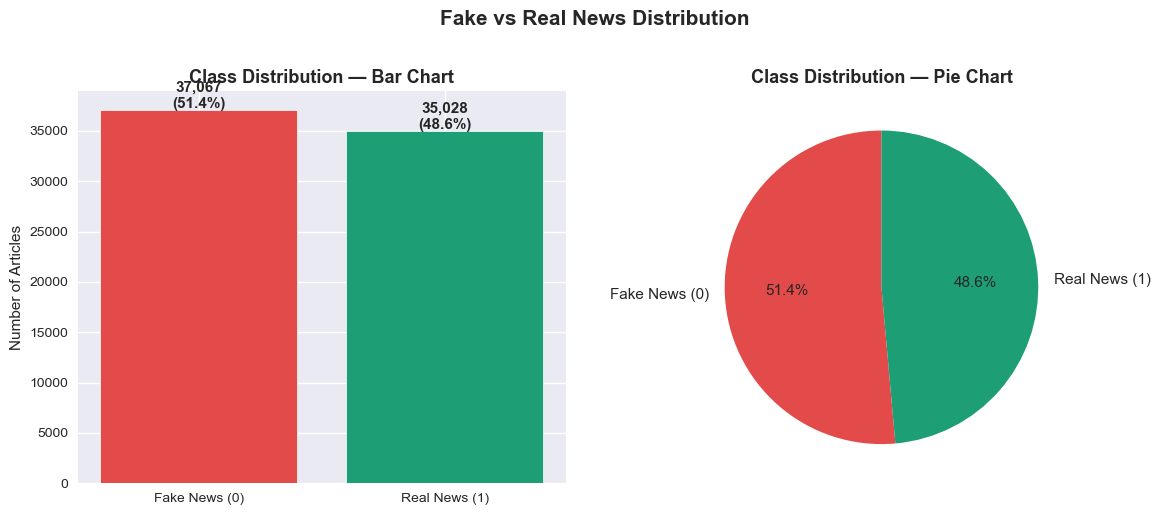

✅ Chart saved to screenshots folder!


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors = ['#E24B4A', '#1D9E75']
counts = df['label'].value_counts()
labels = ['Fake News (0)', 'Real News (1)']

axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('Class Distribution — Bar Chart', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Articles')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}\n({v/len(df)*100:.1f}%)', 
                ha='center', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Class Distribution — Pie Chart', fontsize=13, fontweight='bold')

plt.suptitle('Fake vs Real News Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../screenshots/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to screenshots folder!")

## 3. Article Length Analysis
Comparing the length of fake vs real news articles.

Average article length:
  Fake news: 336 words
  Real news: 286 words

Median article length:
  Fake news: 258 words
  Real news: 210 words


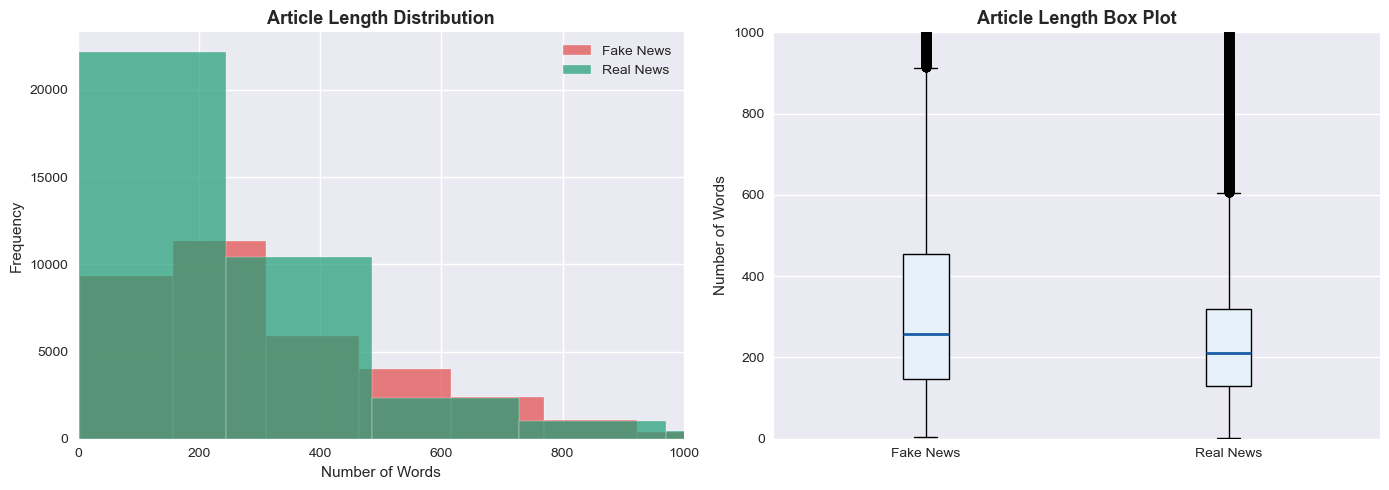

In [5]:
df['text_length'] = df['final_text'].apply(lambda x: len(str(x).split()))

fake = df[df['label'] == 0]['text_length']
real = df[df['label'] == 1]['text_length']

print("Average article length:")
print(f"  Fake news: {fake.mean():.0f} words")
print(f"  Real news: {real.mean():.0f} words")
print(f"\nMedian article length:")
print(f"  Fake news: {fake.median():.0f} words")
print(f"  Real news: {real.median():.0f} words")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(fake, bins=50, alpha=0.7, color='#E24B4A', label='Fake News', edgecolor='white')
axes[0].hist(real, bins=50, alpha=0.7, color='#1D9E75', label='Real News', edgecolor='white')
axes[0].set_title('Article Length Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].set_xlim(0, 1000)

# Box plot
axes[1].boxplot([fake, real], labels=['Fake News', 'Real News'],
                patch_artist=True,
                boxprops=dict(facecolor='#E6F1FB'),
                medianprops=dict(color='#185FA5', linewidth=2))
axes[1].set_title('Article Length Box Plot', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Words')
axes[1].set_ylim(0, 1000)

plt.tight_layout()
plt.savefig('../screenshots/02_article_length.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Word Frequency Analysis
Finding the most common words in fake and real news articles.

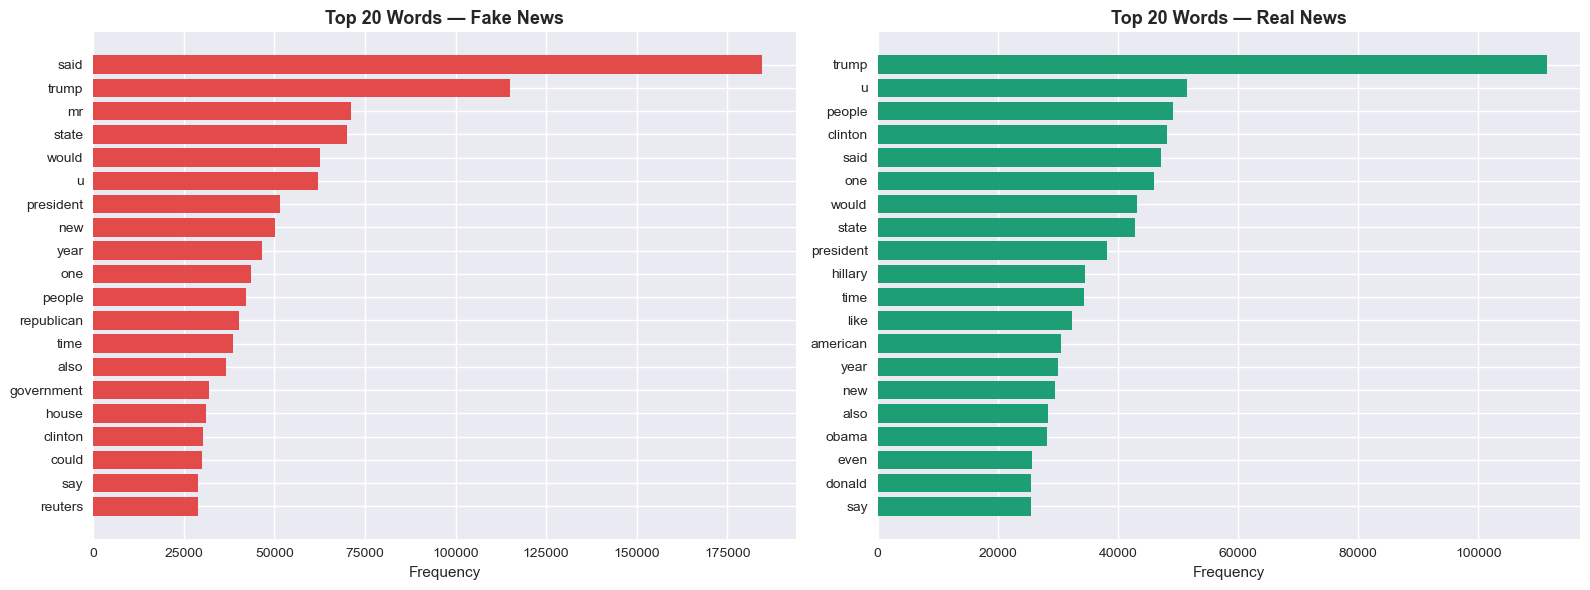

In [6]:
def get_top_words(data, n=20):
    # Convert everything to string and drop NaN values first
    all_words = ' '.join(data.dropna().astype(str)).split()
    return Counter(all_words).most_common(n)

fake_words = get_top_words(df[df['label'] == 0]['final_text'])
real_words = get_top_words(df[df['label'] == 1]['final_text'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Fake news top words
words_f, counts_f = zip(*fake_words)
axes[0].barh(list(reversed(words_f)), list(reversed(counts_f)), color='#E24B4A')
axes[0].set_title('Top 20 Words — Fake News', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Frequency')

# Real news top words
words_r, counts_r = zip(*real_words)
axes[1].barh(list(reversed(words_r)), list(reversed(counts_r)), color='#1D9E75')
axes[1].set_title('Top 20 Words — Real News', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('../screenshots/03_word_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Word Clouds
Visual representation of the most frequent words in each class.

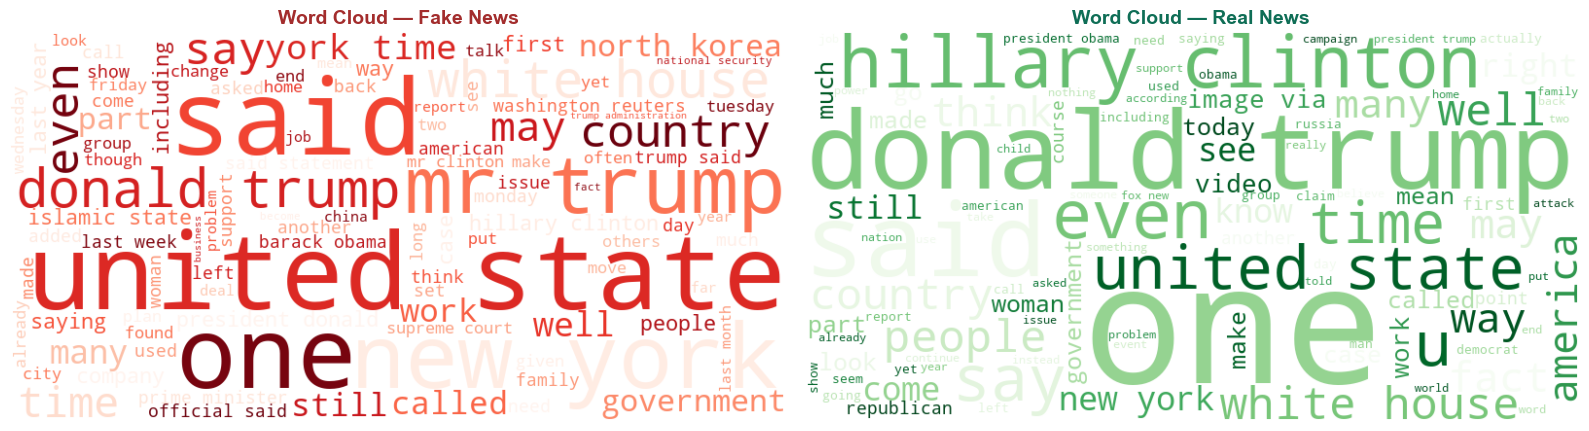

✅ Word clouds generated!


In [7]:
fake_text = ' '.join(df[df['label'] == 0]['final_text'].dropna())
real_text = ' '.join(df[df['label'] == 1]['final_text'].dropna())

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Fake news word cloud
wc_fake = WordCloud(width=800, height=400,
                    background_color='white',
                    colormap='Reds',
                    max_words=100).generate(fake_text)
axes[0].imshow(wc_fake, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Word Cloud — Fake News', fontsize=14, fontweight='bold', color='#A32D2D')

# Real news word cloud
wc_real = WordCloud(width=800, height=400,
                    background_color='white',
                    colormap='Greens',
                    max_words=100).generate(real_text)
axes[1].imshow(wc_real, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Word Cloud — Real News', fontsize=14, fontweight='bold', color='#0F6E56')

plt.tight_layout()
plt.savefig('../screenshots/04_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Word clouds generated!")